<a href="https://colab.research.google.com/github/Prudhvilakshman1112/GEN-AI/blob/main/EXP_8_Diffusion_Models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Cell 1: Environment Setup and Library Installation
Because Stable Diffusion requires specialized libraries, this cell installs the Hugging Face diffusers library and accelerate (which optimizes model loading). We then import the necessary modules and detect if a GPU is available, which is highly recommended for running this model efficiently.

In [ ]:
# Install required libraries
!pip install diffusers accelerate -q

import torch
from diffusers import StableDiffusionPipeline
import matplotlib.pyplot as plt

# Detect device (GPU is required for reasonable speed)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

if device == "cpu":
    print("WARNING: Running Stable Diffusion on CPU will be extremely slow.")

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


Using device: cuda


#Cell 2: Loading the Stable Diffusion Model
This cell downloads and initializes the Stable Diffusion v1.5 model from Hugging Face. We use torch.float16 (half-precision), which significantly reduces the GPU memory required and speeds up generation without a noticeable loss in image quality.

In [ ]:
# Model ID for public non-gated model (v1.5)
model_id = "runwayml/stable-diffusion-v1-5"

print(f"Loading Stable Diffusion 1.5 into {device}...")
# Load the pipeline with half-precision floating point for memory efficiency
pipe = StableDiffusionPipeline.from_pretrained(
    model_id,
    torch_dtype=torch.float16 if device == "cuda" else torch.float32
).to(device)

Loading Stable Diffusion 1.5 into cuda...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

StableDiffusionSafetyChecker LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/safety_checker
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
vision_model.vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


#Cell 3: Configuring Prompts and Generation Parameters
Here, we define what we want the AI to draw. We set a list of creative prompts and a negative_prompt. The negative prompt specifies what we don't want to see in the image (e.g., "blurry" or "deformed"), which helps improve the final aesthetic quality. We also pre-allocate a list to store the generated images.

In [ ]:
prompts = [
    "A serene cyberpunk city at night with neon lights and flying cars, 8k cinematic",
    "A majestic fantasy dragon perched on a mountain peak, epic atmosphere, digital art",
    "Surreal dreamscape with floating islands and glowing waterfalls, Studio Ghibli style",
    "Portrait of a beautiful elf warrior in enchanted forest, intricate details, fantasy art"
]

# Defines elements to avoid in the generated image
negative_prompt = "blurry, low quality, deformed, ugly, bad anatomy, watermark, text, error"
images = []

#Cell 4: Running the Image Generation Loop
This is the core execution cell. We loop through our prompts, sending each one to the pipeline. We define key parameters here:

num_inference_steps: How many times the model refines the image (20 is a good balance of speed/quality).

guidance_scale: How strictly the AI adheres to your prompt (7.5 is standard).
Each generated image is saved locally as a PNG file and added to our list.

In [ ]:
print("Starting Image Generation Loop...")

for i, prompt in enumerate(prompts):
    # Run pipeline with specific parameters
    image = pipe(
        prompt=prompt,
        negative_prompt=negative_prompt,
        num_inference_steps=20, # Number of denoising steps
        guidance_scale=7.5,     # How closely to follow the prompt
        height=512,
        width=512,
        # Use a seed for reproducibility (slightly different for each prompt)
        generator=torch.Generator(device).manual_seed(42 + i)
    ).images[0]

    # Save image to files
    filename = f"sd_art_{i+1}.png"
    image.save(filename)
    images.append(image)
    print(f"Generating image {i+1}/4... ✓ Saved: {filename}")

print("Generation complete!")

Starting Image Generation Loop...


  0%|          | 0/20 [00:00<?, ?it/s]

Generating image 1/4... ✓ Saved: sd_art_1.png


  0%|          | 0/20 [00:00<?, ?it/s]

Generating image 2/4... ✓ Saved: sd_art_2.png


  0%|          | 0/20 [00:00<?, ?it/s]

Generating image 3/4... ✓ Saved: sd_art_3.png


  0%|          | 0/20 [00:00<?, ?it/s]

Generating image 4/4... ✓ Saved: sd_art_4.png
Generation complete!


#Cell 5: Displaying Generated Art
Since the images were generated in a loop, this final cell uses Matplotlib to arrange the results into a clean 1x4 grid for easy viewing directly within the Colab notebook.



Displaying generated art images:


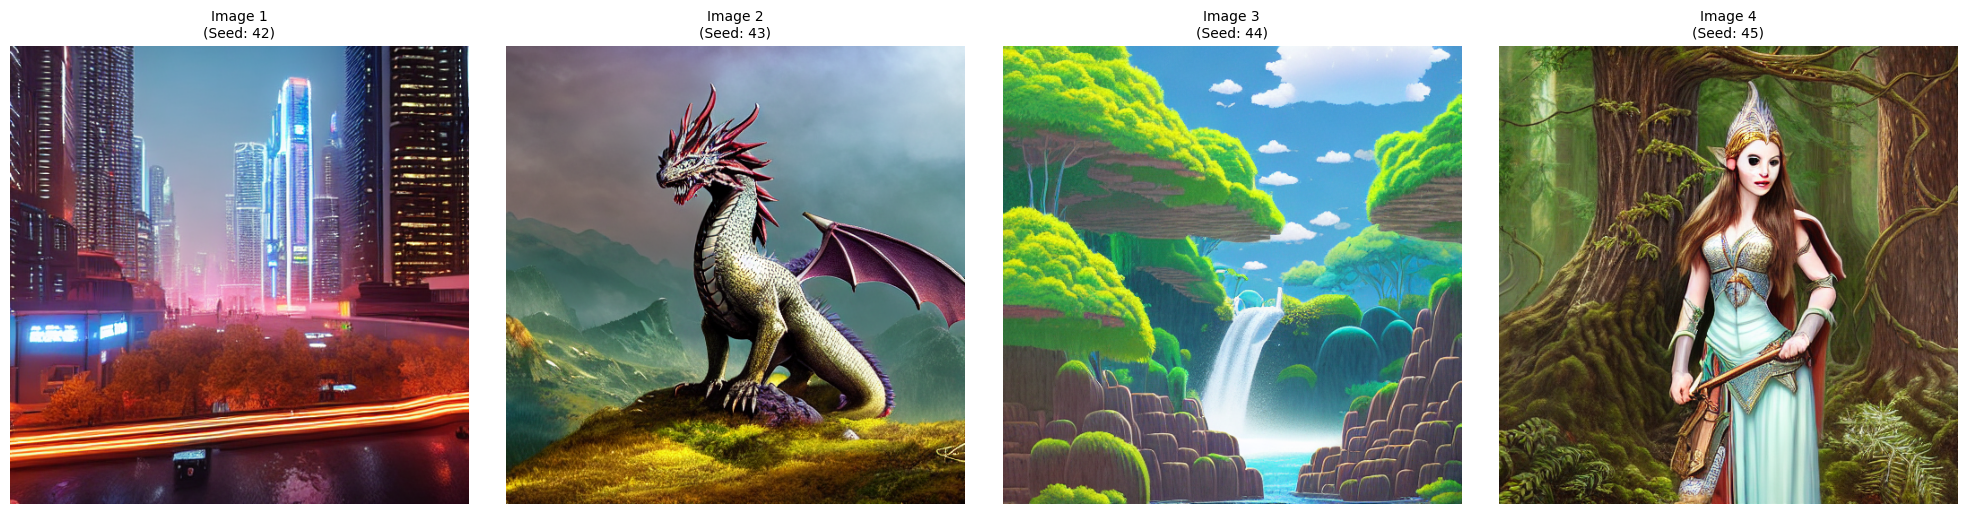

In [ ]:
# === SHOW GENERATED IMAGES ===
print("\nDisplaying generated art images:")
fig, axs = plt.subplots(1, 4, figsize=(20, 5))

for i, img in enumerate(images):
    axs[i].imshow(img)
    axs[i].axis('off') # Hide axes for better viewing
    axs[i].set_title(f"Image {i+1}\n(Seed: {42+i})", fontsize=10)

plt.tight_layout()
plt.show()